In [1]:
import uproot
import awkward as ak
import pandas as pd
import numpy as np

In [2]:
rng = np.random.default_rng(42)

In [9]:
file = uproot.open("../outputs/zmm_delphes.root")
tree = file["Delphes"]

In [10]:
arr = tree.arrays([
    "Particle.PID",
    "Particle.M1",
    "Particle.Px",
    "Particle.Py",
    "Particle.Pz",
    "Particle.X",
    "Particle.Y",
    "Particle.Z",
], library="ak")

In [11]:
r_layers = np.array([300, 500, 700, 900, 1100], dtype=float)  # mm
sigma_x = 1.0  # mm
sigma_y = 1.0  # mm
sigma_z = 2.0  # mm

Starting from the truth muons, let's generate points in the barrel layers by intersecting the trajectory with a cylinder:\
$x(s)^2 + y(s)^2 = r^2$ \
and then replace the coordinates with the extrapolation starting from the truth vertex ($x_0$, $y_0$):\
$
x(s) = x_0 + u_x * s 
$
\
$
y(s) = y_0 + u_y * s 
$
\
then by expanding and solving the quadratic equation of $s$:

In [12]:
def intersect_line_with_cylinder(x0, y0, z0, px, py, pz, r):
    p = np.sqrt(px**2 + py**2 + pz**2)
    if p == 0:
        return None

    ux, uy, uz = px / p, py / p, pz / p

    A = ux**2 + uy**2
    B = 2.0 * (x0 * ux + y0 * uy)
    C = x0**2 + y0**2 - r**2

    if A == 0:
        return None

    disc = B**2 - 4.0 * A * C
    if disc < 0:
        return None

    sqrt_disc = np.sqrt(disc)
    s1 = (-B - sqrt_disc) / (2.0 * A)
    s2 = (-B + sqrt_disc) / (2.0 * A)

    valid = [s for s in (s1, s2) if s > 0]
    if not valid:
        return None

    s = min(valid)

    x = x0 + ux * s
    y = y0 + uy * s
    z = z0 + uz * s

    return x, y, z, s

In [13]:
def make_barrel_hits(x0, y0, z0, px, py, pz, r_layers, sigma_x=1.0, sigma_y=1.0, sigma_z=2.0):
    hits = []

    for r in r_layers:
        hit = intersect_line_with_cylinder(x0, y0, z0, px, py, pz, r)
        if hit is None:
            continue

        x_true, y_true, z_true, s = hit

        x_meas = x_true + rng.normal(0.0, sigma_x)
        y_meas = y_true + rng.normal(0.0, sigma_y)
        z_meas = z_true + rng.normal(0.0, sigma_z)

        phi_true = np.arctan2(y_true, x_true)
        phi_meas = np.arctan2(y_meas, x_meas)

        hits.append({
            "r_layer": r,
            "x_true": x_true,
            "y_true": y_true,
            "z_true": z_true,
            "x_meas": x_meas,
            "y_meas": y_meas,
            "z_meas": z_meas,
            "phi_true": phi_true,
            "phi_meas": phi_meas,
        })

    return hits

In [14]:
all_hits = []

In [15]:
for iev in range(len(arr["Particle.PID"])):
    pid = np.asarray(arr["Particle.PID"][iev])
    m1  = np.asarray(arr["Particle.M1"][iev])
    px  = np.asarray(arr["Particle.Px"][iev], dtype=float)
    py  = np.asarray(arr["Particle.Py"][iev], dtype=float)
    pz  = np.asarray(arr["Particle.Pz"][iev], dtype=float)
    x0  = np.asarray(arr["Particle.X"][iev], dtype=float)
    y0  = np.asarray(arr["Particle.Y"][iev], dtype=float)
    z0  = np.asarray(arr["Particle.Z"][iev], dtype=float)

    event_hits = []

    for i in range(len(pid)):
        if abs(pid[i]) != 13:
            continue
        if m1[i] < 0:
            continue

        mother_index = m1[i]
        if mother_index >= len(pid):
            continue

        #Keep only muons from Z
        if abs(pid[mother_index]) != 23:
            continue

        # Avoid division by tiny pz 
        if abs(pz[i]) < 1e-9:
            continue

        tx = px[i] / pz[i]
        ty = py[i] / pz[i]

        muon_hits = make_barrel_hits(
            x0=x0[i],
            y0=y0[i],
            z0=z0[i],
            px=px[i],
            py=py[i],
            pz=pz[i],
            r_layers=r_layers,
            sigma_x=1.0,
            sigma_y=1.0,
            sigma_z=2.0,
        )

        if len(muon_hits) > 0:
            event_hits.append(muon_hits)

    all_hits.append(event_hits)

print(f"Built synthetic hits for {len(all_hits)} events.")

Built synthetic hits for 10000 events.


In [17]:
rows = []

for iev, event_hits in enumerate(all_hits):
    for imu, muon_hits in enumerate(event_hits):
        for ihit, hit in enumerate(muon_hits):
            rows.append({
                "event_id": iev,
                "muon_id": imu,
                "hit_id": ihit,
                "r_layer": hit["r_layer"],
                "x_true": hit["x_true"],
                "y_true": hit["y_true"],
                "z_true": hit["z_true"],
                "x_meas": hit["x_meas"],
                "y_meas": hit["y_meas"],
                "z_meas": hit["z_meas"],
                "phi_true": hit["phi_true"],
                "phi_meas": hit["phi_meas"],
            })

hits_df = pd.DataFrame(rows)

print(hits_df.head())
print(f"\nTotal hits: {len(hits_df)}")
print(f"Total muon tracks: {hits_df[['event_id', 'muon_id']].drop_duplicates().shape[0]}")

   event_id  muon_id  hit_id  r_layer     x_true       y_true    z_true  \
0         0        0       0    300.0 -16.090726  -299.568170 -2.419227   
1         0        0       1    500.0 -26.817877  -499.280283 -4.032045   
2         0        0       2    700.0 -37.545028  -698.992397 -5.644862   
3         0        0       3    900.0 -48.272179  -898.704510 -7.257680   
4         0        0       4   1100.0 -58.999330 -1098.416624 -8.870498   

      x_meas       y_meas    z_meas  phi_true  phi_meas  
0 -15.786009  -300.608154 -0.918324 -1.624458 -1.623262  
1 -25.877312  -501.231319 -6.636404 -1.624458 -1.622378  
2 -37.417188  -699.308639 -5.678465 -1.624458 -1.624251  
3 -49.125223  -897.825112 -5.702096 -1.624458 -1.625458  
4 -58.933299 -1097.289382 -7.935479 -1.624458 -1.624453  

Total hits: 100000
Total muon tracks: 20000


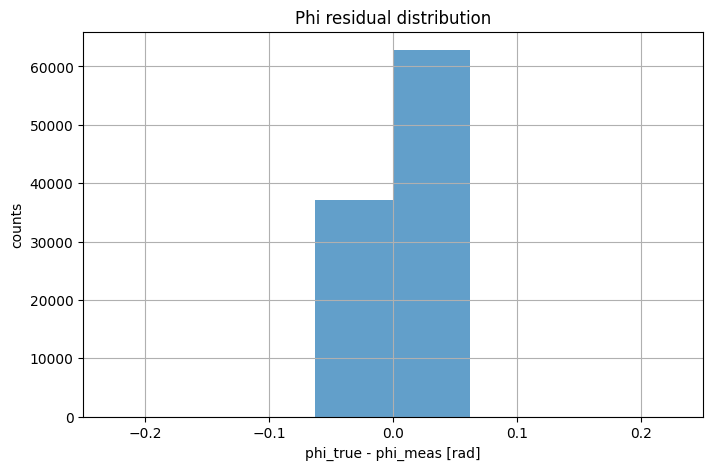

In [ ]:
import matplotlib.pyplot as plt

hits_df["phi_residual"] = hits_df["phi_true"] - hits_df["phi_meas"]

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(hits_df["phi_residual"], bins=200, color="C0", alpha=0.7)
ax.set_xlim(-0.25, 0.25)

ax.set_xlabel("phi_true - phi_meas [rad]")
ax.set_ylabel("counts")
ax.set_title("Phi residual distribution")
ax.grid(True)

plt.show()

In [18]:
hits_df = hits_df.sort_values(["event_id", "muon_id", "r_layer", "hit_id"]).reset_index(drop=True)

In [19]:
print(hits_df.head())


   event_id  muon_id  hit_id  r_layer     x_true       y_true    z_true  \
0         0        0       0    300.0 -16.090726  -299.568170 -2.419227   
1         0        0       1    500.0 -26.817877  -499.280283 -4.032045   
2         0        0       2    700.0 -37.545028  -698.992397 -5.644862   
3         0        0       3    900.0 -48.272179  -898.704510 -7.257680   
4         0        0       4   1100.0 -58.999330 -1098.416624 -8.870498   

      x_meas       y_meas    z_meas  phi_true  phi_meas  
0 -15.786009  -300.608154 -0.918324 -1.624458 -1.623262  
1 -25.877312  -501.231319 -6.636404 -1.624458 -1.622378  
2 -37.417188  -699.308639 -5.678465 -1.624458 -1.624251  
3 -49.125223  -897.825112 -5.702096 -1.624458 -1.625458  
4 -58.933299 -1097.289382 -7.935479 -1.624458 -1.624453  


In [20]:
hits_df.to_csv("hits_df.csv", index=False)